# 🎮 SteamSense

# 02 - Data Understanding (EDA)

## Objectives

- Explore game statistics
- Understand pricing
- Analyze ratings
- Study recommendations
- Discover trends
- Prepare for feature engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [2]:
DATA_PATH = Path("../data/raw")

games = pd.read_csv(DATA_PATH / "games.csv")
recommendations = pd.read_csv(DATA_PATH / "recommendations.csv")

C:\Users\Vedant\AppData\Local\Temp\ipykernel_2012\1682097238.py:4: DtypeWarning: Columns (0: is_recommended) have mixed types. Specify dtype option on import or set low_memory=False.
  recommendations = pd.read_csv(DATA_PATH / "recommendations.csv")


In [3]:
games.head()

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True


In [4]:
games.describe()

,app_id,positive_ratio,user_reviews,price_final,price_original,discount
count,5.087200e+04,50872.000000,5.087200e+04,50872.000000,50872.000000,50872.000000
mean,1.055224e+06,77.052033,1.824425e+03,8.620325,8.726788,5.592212
std,6.103249e+05,18.253592,4.007352e+04,11.514164,11.507021,18.606679
min,1.000000e+01,0.000000,1.000000e+01,0.000000,0.000000,0.000000
25%,5.287375e+05,67.000000,1.900000e+01,0.990000,0.990000,0.000000
50%,9.860850e+05,81.000000,4.900000e+01,4.990000,4.990000,0.000000
75%,1.524895e+06,91.000000,2.060000e+02,10.990000,11.990000,0.000000
max,2.599300e+06,100.000000,7.494460e+06,299.990000,299.990000,90.000000


In [5]:
print(f"Total Games: {len(games):,}")

Total Games: 50,872


In [6]:
free_games = (games["price_final"] == 0).sum()
paid_games = (games["price_final"] > 0).sum()

print(f"Free Games : {free_games:,}")
print(f"Paid Games : {paid_games:,}")

Free Games : 9,105
Paid Games : 41,767


In [7]:
games["price_final"].describe()

count    50872.000000
mean         8.620325
std         11.514164
min          0.000000
25%          0.990000
50%          4.990000
75%         10.990000
max        299.990000
Name: price_final, dtype: float64

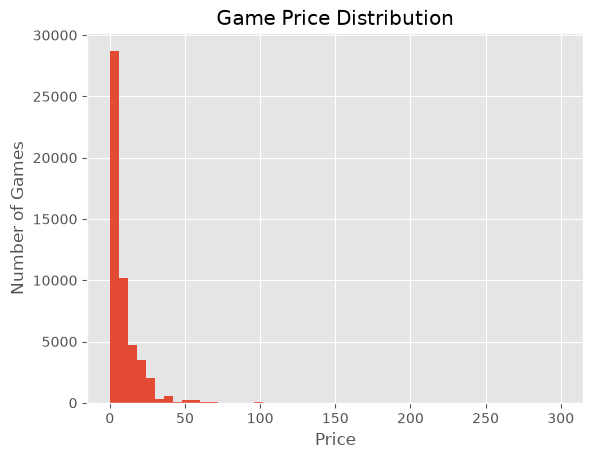

In [8]:
games["price_final"].hist(bins=50)

plt.title("Game Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Games")

plt.show()

In [9]:
games["rating"].value_counts()

rating
Positive                   13502
Very Positive              13139
Mixed                      12157
Mostly Positive             8738
Mostly Negative             1849
Overwhelmingly Positive     1110
Negative                     303
Very Negative                 60
Overwhelmingly Negative       14
Name: count, dtype: int64

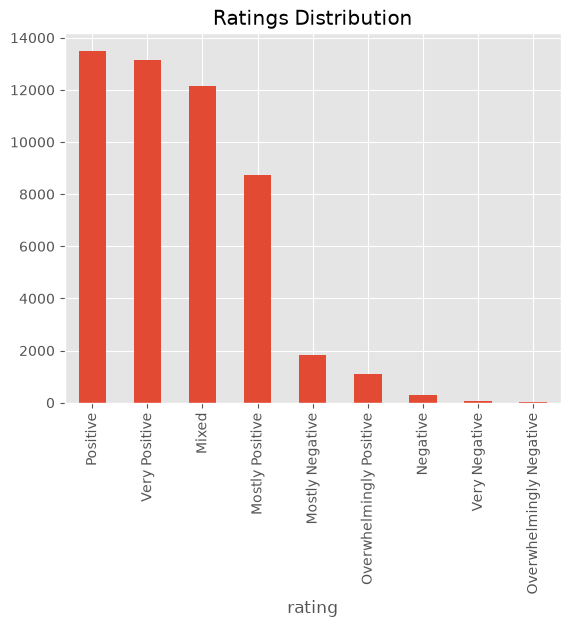

In [10]:
games["rating"].value_counts().plot(kind="bar")

plt.title("Ratings Distribution")

plt.show()

In [11]:
games["positive_ratio"].describe()

count    50872.000000
mean        77.052033
std         18.253592
min          0.000000
25%         67.000000
50%         81.000000
75%         91.000000
max        100.000000
Name: positive_ratio, dtype: float64

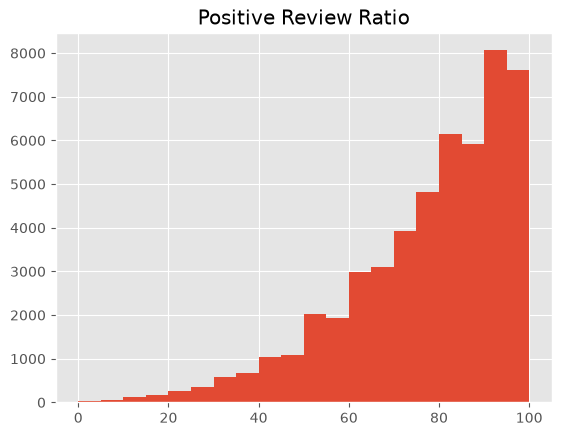

In [12]:
games["positive_ratio"].hist(bins=20)

plt.title("Positive Review Ratio")

plt.show()

In [13]:
games.sort_values(
    by="user_reviews",
    ascending=False
)[["title","user_reviews"]].head(10)

,title,user_reviews
14398,Counter-Strike: Global Offensive,7494460
47770,PUBG: BATTLEGROUNDS,2217226
13176,Dota 2,2045628
12717,Grand Theft Auto V,1484122
14535,Tom Clancy's Rainbow Six® Siege,993312
47380,Team Fortress 2,985819
13035,Terraria,943413
15363,Garry's Mod,853733
13173,Rust,786668
14376,Apex Legends™,713182


In [14]:
games.sort_values(
    by="price_final",
    ascending=False
)[["title","price_final"]].head(10)

,title,price_final
5024,Clickteam Fusion 2.5 Developer Upgrade,299.99
22126,Aartform Curvy 3D 3.0,299.90
19819,Houdini Indie,269.99
81,3DF Zephyr Lite Steam Edition,199.99
12918,Hidden Post-Apocalyptic 3 Top-Down 3D,199.99
13001,Break Everything - Park,199.99
27092,Fly Fly Tuk Tuk,199.99
43973,Derelict (DO NOT BUY),199.99
45760,Hidden Harbor 3 Top-Down 3D,199.99
46951,Hidden Post-Apocalyptic 2 Top-Down 3D,199.99


In [15]:
games["win"].value_counts()

win
True     50076
False      796
Name: count, dtype: int64

In [16]:
games["mac"].value_counts()

mac
False    37854
True     13018
Name: count, dtype: int64

In [17]:
games["linux"].value_counts()

linux
False    41831
True      9041
Name: count, dtype: int64

In [18]:
games["steam_deck"].value_counts()

steam_deck
True     50870
False        2
Name: count, dtype: int64

In [19]:
recommendations.head()

,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
0,975370,0.0,0.0,2022-12-12,True,36.3,51580.0,0.0
1,304390,4.0,0.0,2017-02-17,False,11.5,2586.0,1.0
2,1085660,2.0,0.0,2019-11-17,True,336.5,253880.0,2.0
3,703080,0.0,0.0,2022-09-23,True,27.4,259432.0,3.0
4,526870,0.0,0.0,2021-01-10,True,7.9,23869.0,4.0


In [20]:
recommendations["is_recommended"].value_counts()

is_recommended
True     25138527
False     4061936
Name: count, dtype: int64

In [21]:
recommendations["hours"].describe()

count    2.920046e+07
mean     1.198385e+02
std      1.893659e+02
min      0.000000e+00
25%      1.190000e+01
50%      3.920000e+01
75%      1.307000e+02
max      9.999000e+02
Name: hours, dtype: float64

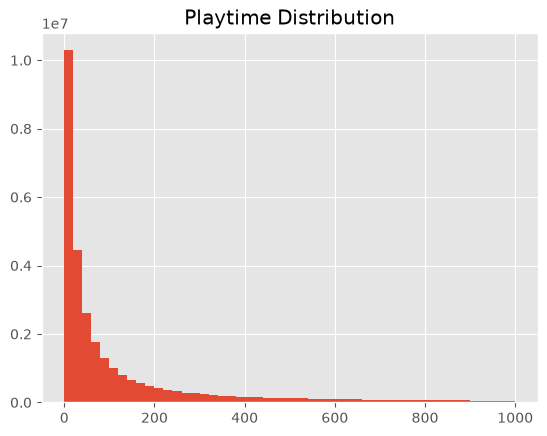

In [22]:
recommendations["hours"].hist(
    bins=50
)

plt.title("Playtime Distribution")

plt.show()

In [23]:
recommendations["app_id"].value_counts().head(10)

app_id
440        319356
252490     252611
1091500    226337
444090     203816
431960     190106
359550     189466
374320     188728
227300     179346
550        178389
730        178113
Name: count, dtype: int64